# **Exoplanet Transit Detection using Machine learning**
## This project explores the use of the supervised machine learning technique. To identify all the exoplanet transit signals from stellar light curves data. We preprocess noisy telescope obeservations and train a classifier to distinguish between stars and  planetary transit.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries loaded sucessfully")

All libraries loaded sucessfully


In [ ]:
import pandas as pd
train_df = pd.read_csv("exoTrain.csv")
train_df.shape

(850, 3198)

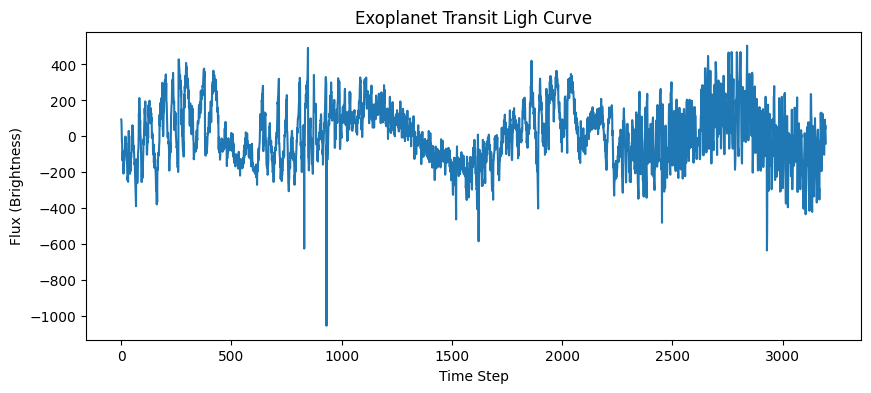

In [ ]:
import matplotlib.pyplot as plt
planet_row = train_df[train_df['LABEL'] ==2].iloc[0]
flux= planet_row.iloc[1:].values
plt.figure(figsize=(10,4))
plt.plot(flux)
plt.xlabel("Time Step")
plt.ylabel("Flux (Brightness)")
plt.title("Exoplanet Transit Ligh Curve")
plt.show()

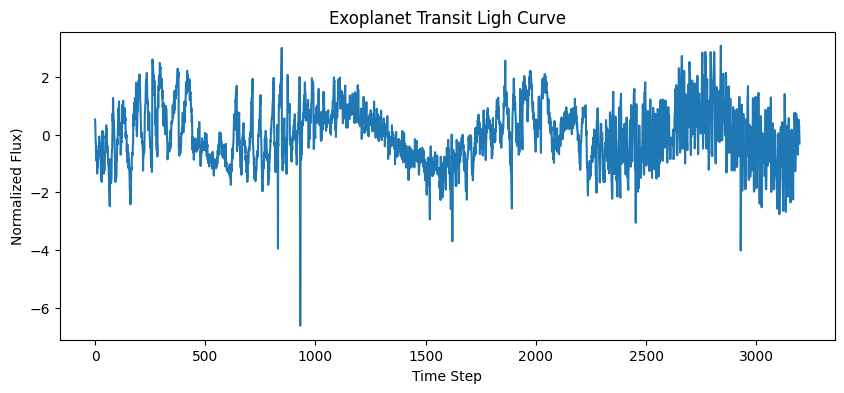

In [ ]:
flux_norm =(flux - flux.mean()) / flux.std()
plt.figure(figsize=(10,4))
plt.plot(flux_norm)
plt.xlabel("Time Step")
plt.ylabel("Normalized Flux)")
plt.title("Exoplanet Transit Ligh Curve")
plt.show("Normalized Exoplaent Transit Light Curve")
plt.show()

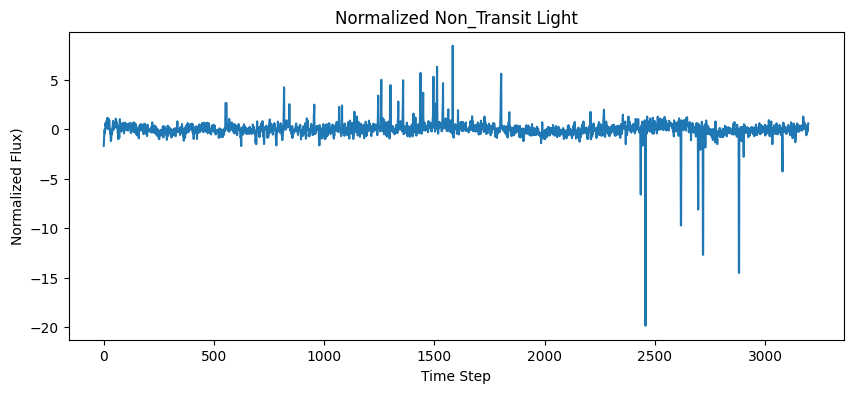

In [ ]:
import matplotlib.pyplot as plt
no_planet_row = train_df[train_df['LABEL'] ==1].iloc[0]
flux_no_planet = no_planet_row.iloc[1:].values

flux_no_planet_norm = (flux_no_planet - flux_no_planet.mean()) / flux_no_planet.std()
plt.figure(figsize=(10,4))
plt.plot(flux_no_planet_norm)
plt.xlabel("Time Step")
plt.ylabel("Normalized Flux)")
plt.title("Normalized Non_Transit Light")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X= train_df.iloc[:,1:].values
y= train_df.iloc[:,0].values

y =(y== 2).astype(int)
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2,
                                                     random_state=42,
                                                     stratify=y)
print(X_train.shape, X_test.shape)

(680, 3197) (170, 3197)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Data Normalized")

Data Normalized


In [ ]:
import numpy as np
print("NaNs in X_train:",
      np.isnan(X_train).sum())
print("NaNs in X_test:",
      np.isnan(X_test).sum())

NaNs in X_train: 1687
NaNs in X_test: 0


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print("NaNs handled using mean imputation")


NaNs handled using mean imputation


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training completed successfully")


Model training completed successfully


In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

[[157   6]
 [  6   1]]
[[157   6]
 [  6   1]]


### **Conclusion**

This project demonstrates an end-to-end machine learning pipeline for exoplanet transit detection using real astronomical time-series data. While the initial model achieves limited recall due to class imbalance, it successfully identifies known exoplanet signals and serves as a foundation for more advanced models such as ensemble methods or deep learning approaches.
